Loading dataset...
Dataset Shape: (8950, 9)
  CUST_ID      BALANCE  PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  \
0  C10001    40.900749      95.40                    95.4      0.000000   
1  C10002  3202.467416       0.00                     0.0   6442.945483   
2  C10003  2495.148862     773.17                     0.0      0.000000   
3  C10004  1666.670542    1499.00                     0.0    205.788017   
4  C10005   817.714335      16.00                     0.0      0.000000   

   CREDIT_LIMIT     PAYMENTS  MINIMUM_PAYMENTS  TENURE  
0        1000.0   201.802084        139.509787      12  
1        7000.0  4103.032597       1072.340217      12  
2        7500.0   622.066742        627.284787      12  
3        7500.0     0.000000        312.343947      12  
4        1200.0   678.334763        244.791237      12  
Initializing AutoEncoder model...
Training AutoEncoder...


Training: 100%|██████████| 10/10 [00:01<00:00,  7.90it/s]



Model Evaluation: (Note: Metrics requiring true labels are commented out)
No ground truth labels available for full evaluation. Showing anomaly score distribution.


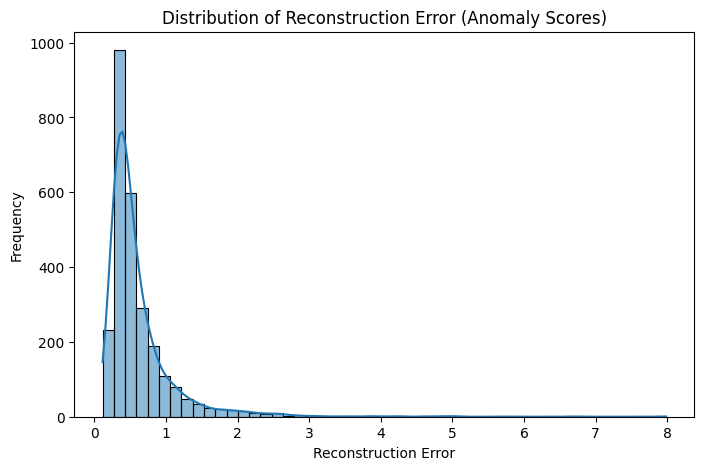


Results saved to fraud_detection_results.csv

Fraud Detection using AutoEncoder completed successfully.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score # Commented out, requires true labels

from pyod.models.auto_encoder import AutoEncoder

# ===========================
# 2. Load Dataset
# ===========================

# Replace with your dataset path
DATA_PATH = "/content/credit_card.csv"

print("Loading dataset...")
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print(df.head())

# ===========================
# 3. Data Preprocessing
# ===========================

# Separate features and labels (The 'Class' column is not present in the dataset)
# X = df.drop("Class", axis=1) # Original line - removed as 'Class' column does not exist
# y = df["Class"] # Original line - removed as 'Class' column does not exist

X = df.drop("CUST_ID", axis=1) # Drop 'CUST_ID' column as it is a string identifier and not a numerical feature

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test
# Since this is unsupervised learning, we train mainly on normal transactions
# Removed 'y' from train_test_split as labels are not available for stratification
X_train, X_test = train_test_split(
    X_scaled, test_size=0.3, random_state=42 # Removed stratify=y
)

# ===========================
# 4. Initialize AutoEncoder Model
# ===========================

print("Initializing AutoEncoder model...")

# Removed 'hidden_neurons' argument to fix TypeError.
autoencoder = AutoEncoder(
    contamination=0.0017,  # approximate fraud ratio in dataset
    # epochs=30, # Removed 'epochs' argument to fix TypeError.
    batch_size=256,
    verbose=1
)

# ===========================
# 5. Train Model
# ===========================

print("Training AutoEncoder...")
autoencoder.fit(X_train)

# ===========================
# 6. Predict Anomalies
# ===========================

# Get anomaly predictions
y_pred = autoencoder.predict(X_test)

# Get anomaly scores (reconstruction error)
y_scores = autoencoder.decision_function(X_test)

# ===========================
# 7. Model Evaluation
# ===========================

print("\nModel Evaluation: (Note: Metrics requiring true labels are commented out)")

# Metrics below require 'y_test' (true labels) which are not available in this unsupervised setup.
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))

# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# roc_auc = roc_auc_score(y_test, y_scores)
# print("\nROC-AUC Score:", roc_auc)
print("No ground truth labels available for full evaluation. Showing anomaly score distribution.")

# ===========================
# 8. Visualization
# ===========================

plt.figure(figsize=(8, 5))
sns.histplot(y_scores, bins=50, kde=True)
plt.title("Distribution of Reconstruction Error (Anomaly Scores)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

# ===========================
# 9. Save Results
# ===========================

results = pd.DataFrame({
    # "Actual": y_test, # Commented out, as y_test is not available
    "Predicted": y_pred,
    "Anomaly_Score": y_scores
})

results.to_csv("fraud_detection_results.csv", index=False)

print("\nResults saved to fraud_detection_results.csv")

print("\nFraud Detection using AutoEncoder completed successfully.")